
# Day 4 Assignment AI in Healthcare: Building a Life-Saving Heart Disease Predictor

##Name: Divyashree R

### Project Overview

Building a machine learning model that predicts whether a patient is likely to have heart disease based on various medical attributes such as age, cholesterol level, chest pain type, and heart rate.

The project demonstrates a complete machine learning workflow including:
- Exploratory Data Analysis (EDA)
- Data preprocessing
- Model training
- Model evaluation

Also, the goal is to do the preprocessing steps such as handling missing values and feature scaling, and training a classification model manually without using pipelines.

Google Colab Link: https://colab.research.google.com/drive/1b3cjHl7_i_kbF9Z-vCpbEsr1n00eWDeU?usp=sharing

In [34]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

# Classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# Evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [35]:
import kagglehub

In [36]:
path = kagglehub.dataset_download("redwankarimsony/heart-disease-data")

# Load the dataset from the downloaded path
file_path = f'{path}/heart_disease_uci.csv'
df = pd.read_csv(file_path)

print("Dataset downloaded and loaded successfully.")
print(f"Data shape: {df.shape}")
df.head()

Using Colab cache for faster access to the 'heart-disease-data' dataset.
Dataset downloaded and loaded successfully.
Data shape: (920, 16)


,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [37]:
df.shape

(920, 16)

In [38]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


In [39]:
df.isna().sum()

,0
id,0
age,0
sex,0
dataset,0
cp,0
trestbps,59
chol,30
fbs,90
restecg,2
thalch,55


In [40]:
# Check target value distribution
df['num'].value_counts()

,count
num,
0,411
1,265
2,109
3,107
4,28


In [41]:
# Convert to binary classification

df['num'] = df['num'].apply(lambda x: 1 if x > 0 else 0)

df['num'].value_counts()

,count
num,
1,509
0,411


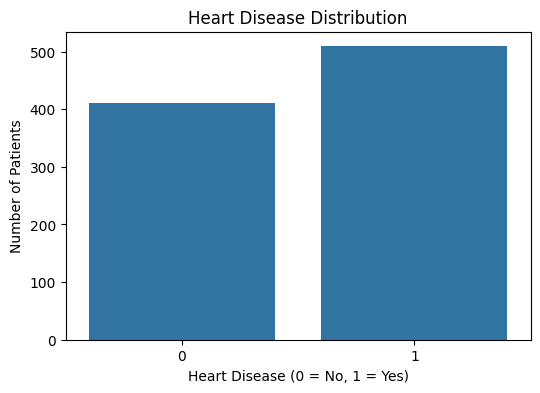

In [42]:
# Distribution of Heart disease cases
plt.figure(figsize=(6,4))

sns.countplot(x='num', data=df)

plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease (0 = No, 1 = Yes)")
plt.ylabel("Number of Patients")

plt.show()

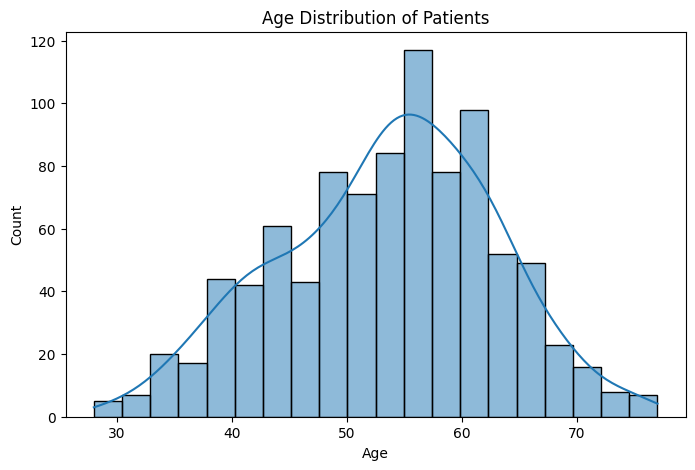

In [43]:
# Age Distribution of Patients
plt.figure(figsize=(8,5))

sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution of Patients")
plt.xlabel("Age")
plt.ylabel("Count")

plt.show()

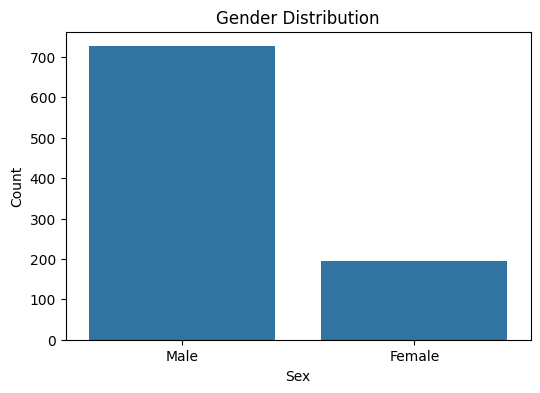

In [44]:
# Gender Distribution
plt.figure(figsize=(6,4))

sns.countplot(x='sex', data=df)

plt.title("Gender Distribution")
plt.xlabel("Sex")
plt.ylabel("Count")

plt.show()

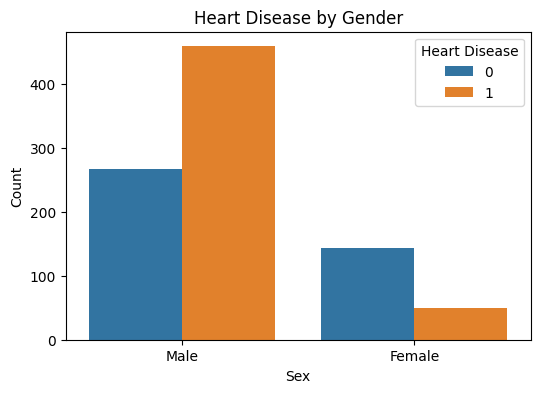

In [45]:
# Heart Disease vs Gender
plt.figure(figsize=(6,4))

sns.countplot(x='sex', hue='num', data=df)

plt.title("Heart Disease by Gender")
plt.xlabel("Sex")
plt.ylabel("Count")
plt.legend(title="Heart Disease")

plt.show()

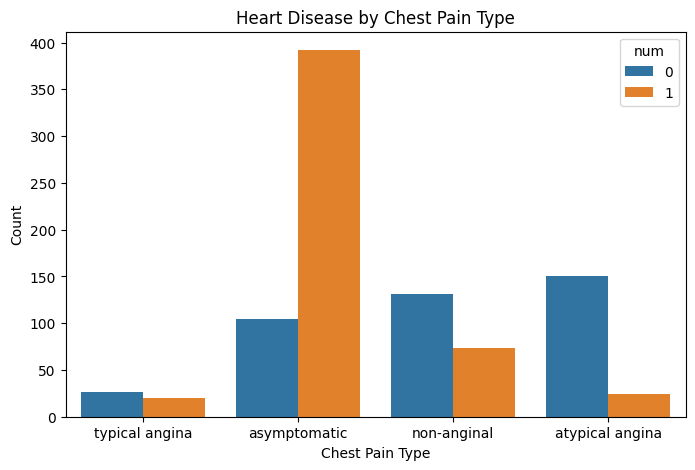

In [46]:
# Chest pai analysis
plt.figure(figsize=(8,5))

sns.countplot(x='cp', hue='num', data=df)

plt.title("Heart Disease by Chest Pain Type")
plt.xlabel("Chest Pain Type")
plt.ylabel("Count")

plt.show()

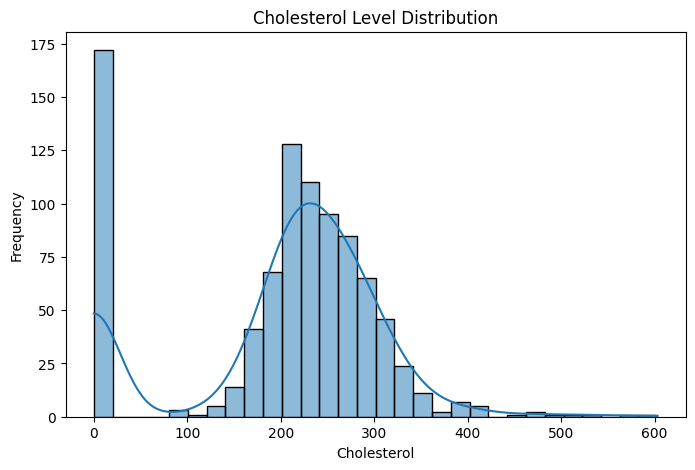

In [47]:
# Cholesterol Level Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['chol'], bins=30, kde=True)

plt.title("Cholesterol Level Distribution")
plt.xlabel("Cholesterol")
plt.ylabel("Frequency")

plt.show()

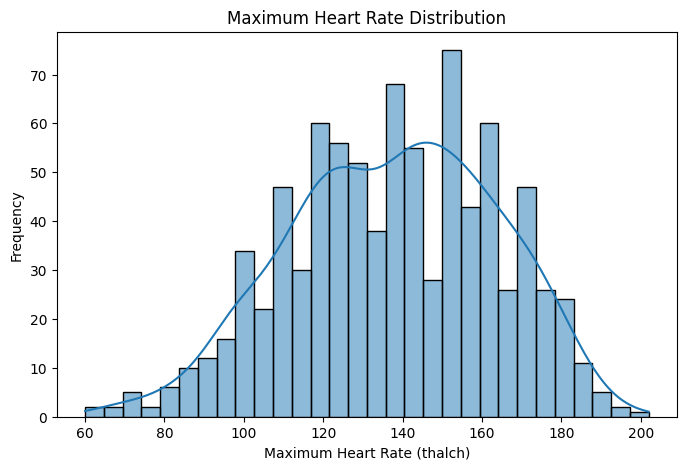

In [48]:
# Maximum Heart Rate Distribution
plt.figure(figsize=(8,5))

sns.histplot(df['thalch'], bins=30, kde=True)

plt.title("Maximum Heart Rate Distribution")
plt.xlabel("Maximum Heart Rate (thalch)")
plt.ylabel("Frequency")

plt.show()

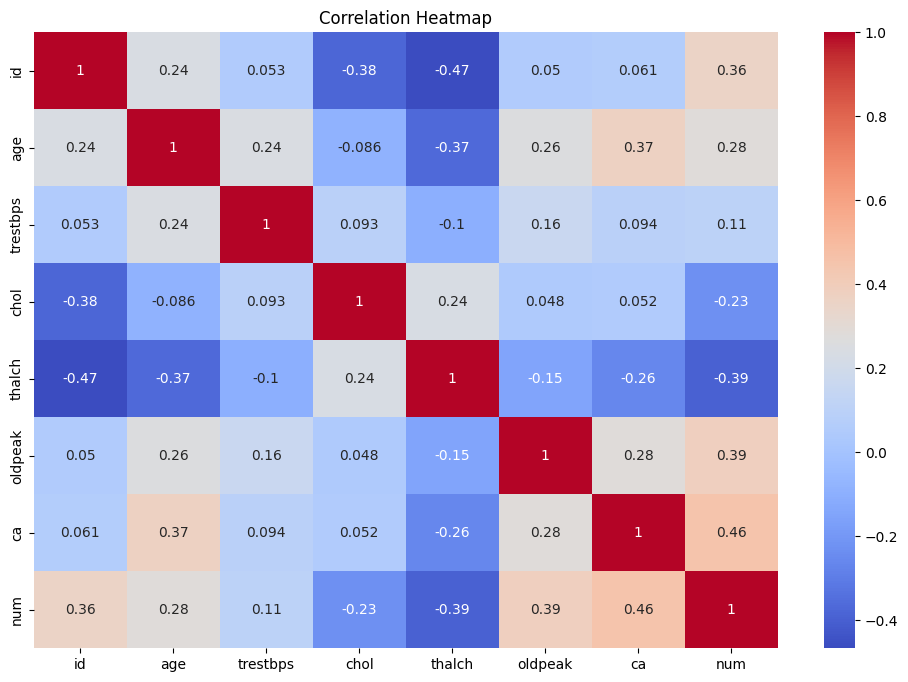

In [49]:
# Correlation Matrix
plt.figure(figsize=(12,8))

sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

In [50]:
# Drop unnecessary columns

df = df.drop(['id','dataset'], axis=1)

df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


## Separating Features and Target Variable

The dataset is divided into:

- **Features (X)** → input variables used for prediction
- **Target (y)** → the variable we want to predict (heart disease)

In [51]:
# Features
X = df.drop('num', axis=1)

# Target
y = df['num']

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal


## Splitting Data into Training and Testing Sets

The dataset is divided into training and testing subsets.

- **Training set** → used to train the model
- **Testing set** → used to evaluate the model's performance

We use an 80–20 split for this purpose.

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42)

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (736, 13)
Testing data shape: (184, 13)


## Handling Missing Values


In [53]:
from sklearn.impute import SimpleImputer

# Separate numerical and categorical columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# Numerical imputer
num_imputer = SimpleImputer(strategy='mean')

X_train[num_cols] = num_imputer.fit_transform(X_train[num_cols])
X_test[num_cols] = num_imputer.transform(X_test[num_cols])

# Categorical imputer
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[cat_cols] = cat_imputer.fit_transform(X_train[cat_cols])
X_test[cat_cols] = cat_imputer.transform(X_test[cat_cols])

X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal
880,62.0,Male,asymptomatic,131.668596,170.000000,False,st-t abnormality,120.000000,True,3.000000,flat,0.688,normal
457,54.0,Male,non-anginal,150.000000,197.763713,False,normal,122.000000,False,0.000000,flat,0.688,normal
797,51.0,Male,non-anginal,131.668596,339.000000,False,normal,137.383285,False,0.881187,flat,0.688,normal
25,50.0,Female,non-anginal,120.000000,219.000000,False,normal,158.000000,False,1.600000,flat,0.000,normal
84,52.0,Male,atypical angina,120.000000,325.000000,False,normal,172.000000,False,0.200000,upsloping,0.000,normal


In [54]:
# Convert categorical variables using one-hot encoding

X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

# Align columns in case encoding creates mismatch
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

X_train.head()

,age,trestbps,chol,thalch,oldpeak,ca,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
880,62.0,131.668596,170.000000,120.000000,3.000000,0.688,True,False,False,False,False,False,True,True,True,False,True,False
457,54.0,150.000000,197.763713,122.000000,0.000000,0.688,True,False,True,False,False,True,False,False,True,False,True,False
797,51.0,131.668596,339.000000,137.383285,0.881187,0.688,True,False,True,False,False,True,False,False,True,False,True,False
25,50.0,120.000000,219.000000,158.000000,1.600000,0.000,False,False,True,False,False,True,False,False,True,False,True,False
84,52.0,120.000000,325.000000,172.000000,0.200000,0.000,True,True,False,False,False,True,False,False,False,True,True,False


##Feature Scaling

In [55]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

##Training Logistic Regression Model

In [56]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)

log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

### Model Predictions

In [57]:
y_pred_log = log_model.predict(X_test_scaled)

y_pred_log[:10]

array([0, 0, 1, 1, 0, 0, 0, 1, 1, 0])

###Logistic Regression Model Evaluation

In [58]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_test, y_pred_log)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_log))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_log))

Accuracy: 0.8043478260869565

Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.83      0.78        75
           1       0.87      0.79      0.83       109

    accuracy                           0.80       184
   macro avg       0.80      0.81      0.80       184
weighted avg       0.81      0.80      0.81       184


Confusion Matrix:
[[62 13]
 [23 86]]


###Logistic Regression Model Confusion Matrix Plotting

---



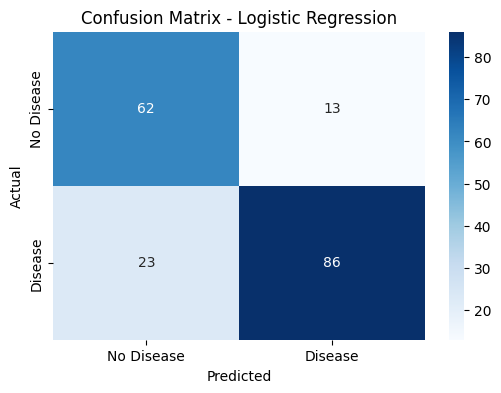

In [59]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm_log = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure(figsize=(6,4))

sns.heatmap(cm_log,
            annot=True,
            fmt="d",
            cmap="Blues",
            xticklabels=["No Disease","Disease"],
            yticklabels=["No Disease","Disease"])

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##Training Random Forest Model

In [60]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)

rf_model.fit(X_train_scaled, y_train)

RandomForestClassifier(random_state=42)

In [61]:
y_pred_rf = rf_model.predict(X_test_scaled)

###Random Forest Model Evaluation

In [62]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:", rf_accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_rf))

Random Forest Accuracy: 0.8478260869565217

Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.87      0.82        75
           1       0.90      0.83      0.87       109

    accuracy                           0.85       184
   macro avg       0.84      0.85      0.84       184
weighted avg       0.85      0.85      0.85       184


Confusion Matrix:
[[65 10]
 [18 91]]


###Random Forest Model Confusion Matrix Plotting

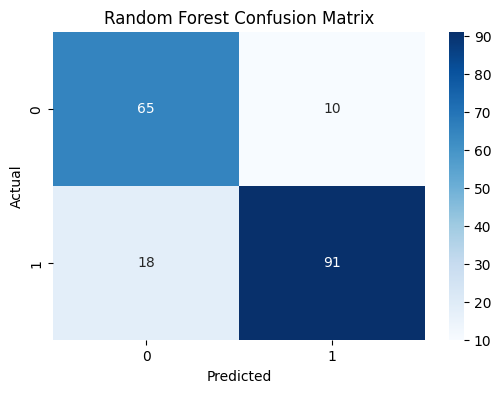

In [63]:
plt.figure(figsize=(6,4))

sns.heatmap(confusion_matrix(y_test, y_pred_rf),
            annot=True,
            fmt="d",
            cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

##Model Comparison

In [64]:
model_results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy]
})

model_results

,Model,Accuracy
0,Logistic Regression,0.804348
1,Random Forest,0.847826


## Final Conclusion

In this project, I built a machine learning system to predict the presence of heart disease using patient medical attributes. I began by performing **Exploratory Data Analysis (EDA)** to understand the dataset, analyze feature distributions, and identify missing values.

During preprocessing, I manually handled missing values, encoded categorical variables, and applied feature scaling. These steps ensured that the dataset was suitable for training machine learning models without using Scikit-Learn pipelines, as required by the assignment.

Two classification models were trained and evaluated:

- **Logistic Regression**
- **Random Forest**

The models were evaluated using **accuracy, classification report, and confusion matrix** to assess their performance. Logistic Regression achieved an accuracy of approximately **80%**, while Random Forest achieved a higher accuracy of approximately **85%**, making it the better-performing model for this dataset.